# 01 — Data Analysis & EDA
> Understand the dataset before touching any model. This notebook covers distribution analysis, class imbalance study, feature inspection, and time-based drift zones.

In [1]:
# Load dataset & basic info
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")


Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


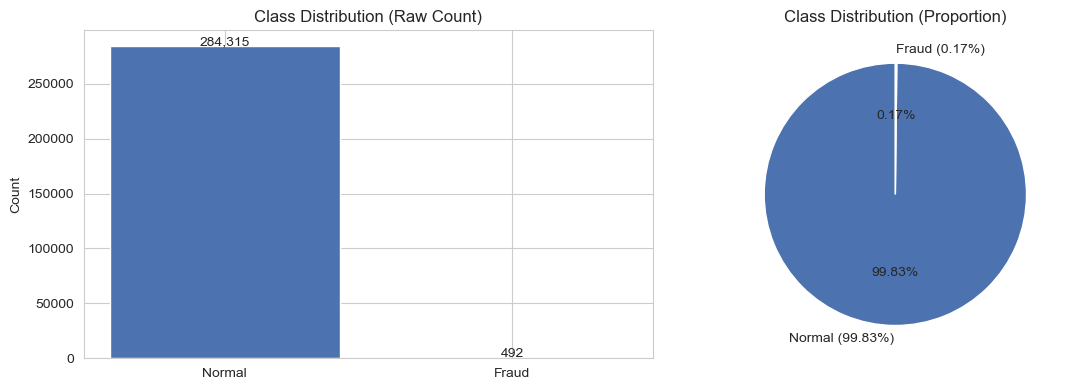

Severe class imbalance detected: 1 fraud per ~578 normal transactions


In [2]:
# Class imbalance analysis
# ---- 1. Class Imbalance ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Normal', 'Fraud'], counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title("Class Distribution (Raw Count)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha='center', fontsize=10)

axes[1].pie(counts.values, labels=['Normal (99.83%)', 'Fraud (0.17%)'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.2f%%', startangle=90)
axes[1].set_title("Class Distribution (Proportion)")
plt.tight_layout()
plt.savefig("outputs/01_class_distribution.png", dpi=120, bbox_inches='tight')
plt.show()
print("Severe class imbalance detected: 1 fraud per ~578 normal transactions")


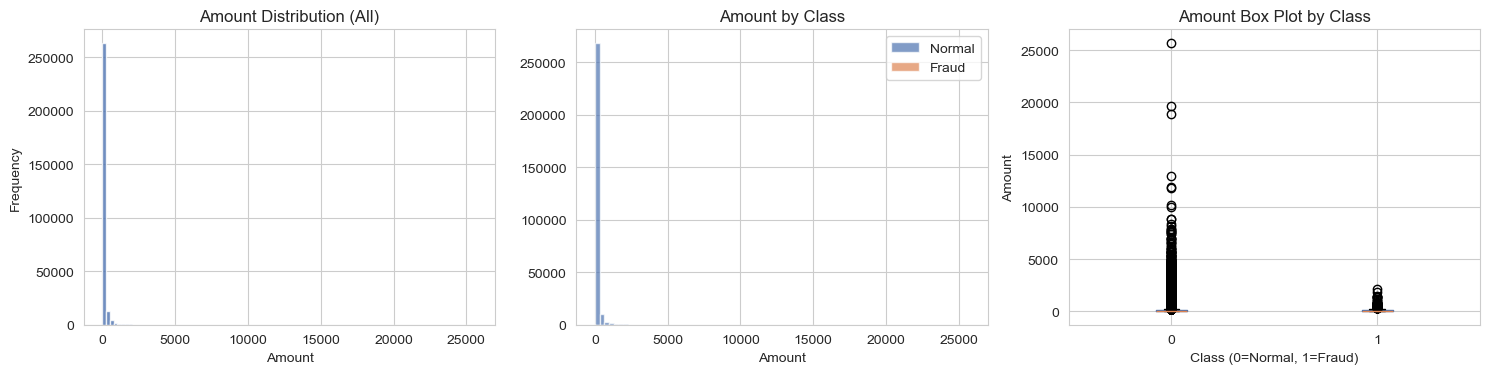

Normal   - Mean: 88.29, Median: 22.00, Max: 25691.16
Fraud    - Mean: 122.21, Median: 9.25, Max: 2125.87


In [3]:
# Transaction amount analysis
# ---- 2. Transaction Amount Analysis ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution
axes[0].hist(df['Amount'], bins=100, color='#4C72B0', alpha=0.8)
axes[0].set_title("Amount Distribution (All)")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Frequency")

# By class
fraud = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']

axes[1].hist(normal, bins=80, alpha=0.7, label='Normal', color='#4C72B0')
axes[1].hist(fraud, bins=80, alpha=0.7, label='Fraud', color='#DD8452')
axes[1].set_title("Amount by Class")
axes[1].legend()
axes[1].set_xlabel("Amount")

# Box plot
df.boxplot(column='Amount', by='Class', ax=axes[2], 
           boxprops=dict(color='#4C72B0'),
           medianprops=dict(color='#DD8452'))
axes[2].set_title("Amount Box Plot by Class")
axes[2].set_xlabel("Class (0=Normal, 1=Fraud)")
axes[2].set_ylabel("Amount")
plt.suptitle("")

plt.tight_layout()
plt.savefig("outputs/01_amount_analysis.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Normal   - Mean: {normal.mean():.2f}, Median: {normal.median():.2f}, Max: {normal.max():.2f}")
print(f"Fraud    - Mean: {fraud.mean():.2f}, Median: {fraud.median():.2f}, Max: {fraud.max():.2f}")


Fraud rate across time windows (this is where concept drift lives):
                     total  fraud_count  fraud_rate  fraud_rate_pct
time_window                                                        
Window_1 (Day1_AM)   78583          191    0.002431        0.243055
Window_2 (Day1_PM)   83941          165    0.001966        0.196567
Window_3 (Day2)     122281          136    0.001112        0.111219


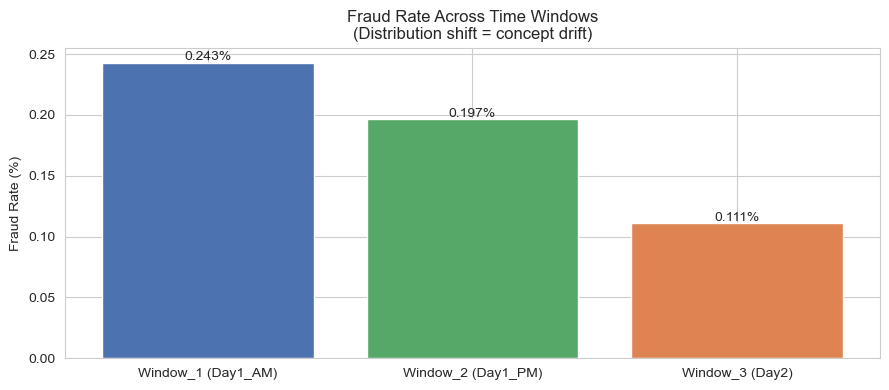

In [4]:
# Time windows — concept drift zones
# ---- 3. Time-Based Drift Zones ----
# Time feature represents seconds. Split into 3 time windows (simulates real-world time drift)
df['time_window'] = pd.cut(df['Time'],
    bins=[0, 57600, 115200, df['Time'].max()],
    labels=['Window_1 (Day1_AM)', 'Window_2 (Day1_PM)', 'Window_3 (Day2)'])

time_stats = df.groupby('time_window')['Class'].agg(['count', 'sum', 'mean'])
time_stats.columns = ['total', 'fraud_count', 'fraud_rate']
time_stats['fraud_rate_pct'] = time_stats['fraud_rate'] * 100

print("Fraud rate across time windows (this is where concept drift lives):")
print(time_stats.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(time_stats.index, time_stats['fraud_rate_pct'], 
              color=['#4C72B0', '#55A868', '#DD8452'])
ax.set_title("Fraud Rate Across Time Windows\n(Distribution shift = concept drift)")
ax.set_ylabel("Fraud Rate (%)")
for bar, val in zip(bars, time_stats['fraud_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f"{val:.3f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("outputs/01_time_drift_zones.png", dpi=120, bbox_inches='tight')
plt.show()


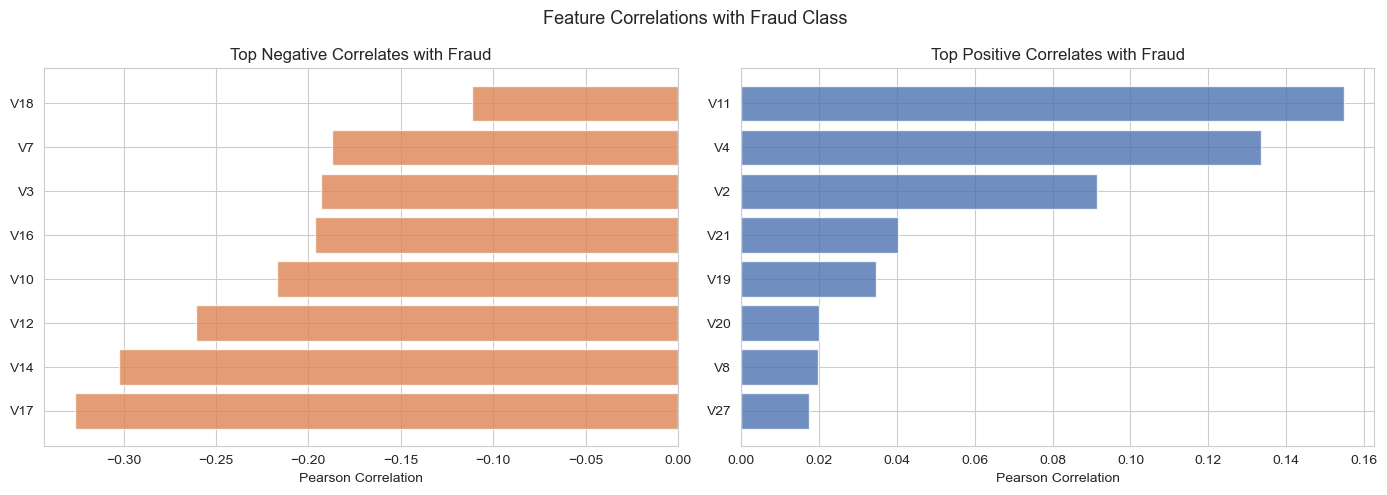

Key features most associated with fraud (high absolute correlation):
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [6]:
# Feature-fraud correlation analysis
# ---- 4. Feature Correlation ----
# V1-V28 are PCA-transformed — we check which correlate most with fraud
corr_with_fraud = df.drop(['Time', 'time_window'], axis=1).corr()['Class'].drop('Class').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top positive correlates (more associated with fraud)
top_pos = corr_with_fraud.tail(8)
top_neg = corr_with_fraud.head(8)

axes[0].barh(top_neg.index, top_neg.values, color='#DD8452', alpha=0.8)
axes[0].set_title("Top Negative Correlates with Fraud")
axes[0].set_xlabel("Pearson Correlation")

axes[1].barh(top_pos.index, top_pos.values, color='#4C72B0', alpha=0.8)
axes[1].set_title("Top Positive Correlates with Fraud")
axes[1].set_xlabel("Pearson Correlation")

plt.suptitle("Feature Correlations with Fraud Class", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/01_feature_correlations.png", dpi=120, bbox_inches='tight')
plt.show()

print("Key features most associated with fraud (high absolute correlation):")
print(corr_with_fraud.abs().sort_values(ascending=False).head(10))


In [7]:
# PSI preview — distribution shift between time windows
# ---- 5. Population Stability Index Preview ----
# PSI measures how much a distribution has shifted between two windows
# We preview this here; full drift detection is in NB03

def compute_psi(expected, actual, buckets=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)
    
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    # Avoid division by zero
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)
    
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

window1 = df[df['time_window'] == 'Window_1 (Day1_AM)']
window3 = df[df['time_window'] == 'Window_3 (Day2)']

psi_results = {}
for col in ['V1', 'V2', 'V3', 'V4', 'V14', 'Amount']:
    psi_val = compute_psi(window1[col].values, window3[col].values)
    psi_results[col] = psi_val

psi_df = pd.DataFrame({'Feature': list(psi_results.keys()), 'PSI': list(psi_results.values())})
psi_df['Severity'] = pd.cut(psi_df['PSI'], bins=[-np.inf, 0.1, 0.2, np.inf],
                             labels=['Stable', 'Moderate Drift', 'High Drift'])
print("PSI Summary (Window1 vs Window3):")
print(psi_df.to_string(index=False))
print("\nPSI Interpretation: <0.1 Stable | 0.1-0.2 Monitor | >0.2 Significant drift")
plt.tight_layout()


PSI Summary (Window1 vs Window3):
Feature      PSI       Severity
     V1 1.077531     High Drift
     V2 0.022031         Stable
     V3 1.520041     High Drift
     V4 0.210819     High Drift
    V14 0.130357 Moderate Drift
 Amount 0.007475         Stable

PSI Interpretation: <0.1 Stable | 0.1-0.2 Monitor | >0.2 Significant drift


<Figure size 1000x500 with 0 Axes>

In [8]:
# Save EDA summary stats
# ---- Summary: Save EDA Stats ----
import json, os
os.makedirs("outputs", exist_ok=True)

eda_summary = {
    "total_records": int(len(df)),
    "fraud_count": int(df['Class'].sum()),
    "normal_count": int((df['Class'] == 0).sum()),
    "fraud_rate_pct": round(df['Class'].mean() * 100, 4),
    "amount_fraud_mean": round(fraud.mean(), 2),
    "amount_normal_mean": round(normal.mean(), 2),
    "n_features": int(df.shape[1] - 1),
    "time_windows": time_stats['fraud_rate_pct'].round(4).to_dict(),
    "top_fraud_corr_features": corr_with_fraud.abs().sort_values(ascending=False).head(5).index.tolist()
}

with open("outputs/eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=4)

print("EDA Summary saved to outputs/eda_summary.json")
print(json.dumps(eda_summary, indent=2))


EDA Summary saved to outputs/eda_summary.json
{
  "total_records": 284807,
  "fraud_count": 492,
  "normal_count": 284315,
  "fraud_rate_pct": 0.1727,
  "amount_fraud_mean": 122.21,
  "amount_normal_mean": 88.29,
  "n_features": 31,
  "time_windows": {
    "Window_1 (Day1_AM)": 0.2431,
    "Window_2 (Day1_PM)": 0.1966,
    "Window_3 (Day2)": 0.1112
  },
  "top_fraud_corr_features": [
    "V17",
    "V14",
    "V12",
    "V10",
    "V16"
  ]
}
